## Load Data Hasil Ramalan SARIMAX
Baca dataset prediksi forecasted_climate_2016_2026.csv (validasi 2016–2025 + proyeksi 2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data hasil peramalan
# index_col=0: menggunakan kolom pertama (yang namanya kosong) sebagai index
# parse_dates=True: otomatis membaca teks tanggal menjadi tipe data Datetime
df_forecast = pd.read_csv('dataset/forecasted_climate_2016_2026.csv', index_col=0, parse_dates=True)

# 2. Beri nama index-nya secara manual agar rapi di dalam Python
df_forecast.index.name = 'time'
df_forecast.index.freq = 'MS'

# Tampilkan data untuk memastikan kolom dibaca dengan benar
print(df_forecast.head())

            temperature_2m_mean  temperature_2m_mean_lower  \
time                                                         
2016-01-01            24.680174                  24.284780   
2016-02-01            24.575620                  24.123244   
2016-03-01            25.001606                  24.502328   
2016-04-01            25.076056                  24.553310   
2016-05-01            25.094871                  24.556979   

            temperature_2m_mean_upper  precipitation_sum  \
time                                                       
2016-01-01                  25.075568         302.630365   
2016-02-01                  25.027995         381.559102   
2016-03-01                  25.500885         352.263878   
2016-04-01                  25.598801         306.649674   
2016-05-01                  25.632763         241.103454   

            precipitation_sum_lower  precipitation_sum_upper  \
time                                                           
2016-01-01      

## Definisikan Parameter Ambang Batas 

In [2]:
# Konstanta ambang batas kesesuaian padi sawah
CYCLE_MONTHS = 4

# 1. Curah Hujan (mm/bulan)
RAIN_MIN = 150
RAIN_MAX = 500
RAIN_OPT_MIN = 180
RAIN_OPT_MAX = 250  # Best case rata-rata ~200 mm

# 2. Suhu Udara (°C)
TEMP_AIR_MIN = 24
TEMP_AIR_MAX = 29

# 3. Suhu Tanah (°C)
TEMP_SOIL_MIN = 20
TEMP_SOIL_MAX = 32

# 4. Kelembaban Tanah (m³/m³) - estimasi dari data Bogor
MOIST_MIN = 0.40
MOIST_MAX = 0.50

## Hitung Rata-rata 4-Month Rolling Window

Untuk setiap bulan T, menghitung rata-rata kondisi iklim untuk 4 bulan ke depan (T,T+1,T+2,T+3) menggunakan fungsi .rolling(window=4).mean() dan menggesernya ke atas menggunakan .shift(-3)

In [3]:
# Buat dataframe baru untuk analisis siklus 4 bulanan
df_cycle = pd.DataFrame(index=df_forecast.index)

# Hitung rata-rata bergerak 4 bulan ke depan untuk nilai prediksi rata-rata (mean)
df_cycle['avg_rain'] = df_forecast['precipitation_sum'].rolling(window=4).mean().shift(-3)
df_cycle['avg_temp_air'] = df_forecast['temperature_2m_mean'].rolling(window=4).mean().shift(-3)
df_cycle['avg_temp_soil'] = df_forecast['soil_temperature_0_7cm_mean'].rolling(window=4).mean().shift(-3)
df_cycle['avg_moist'] = df_forecast['soil_moisture_0_7cm_mean'].rolling(window=4).mean().shift(-3)

# Hitung juga untuk skenario batas bawah (lower bound) untuk analisis risiko kekeringan
df_cycle['avg_rain_lower'] = df_forecast['precipitation_sum_lower'].rolling(window=4).mean().shift(-3)
df_cycle['avg_moist_lower'] = df_forecast['soil_moisture_0_7cm_mean_lower'].rolling(window=4).mean().shift(-3)

# Hitung skenario batas atas (upper bound) untuk analisis risiko banjir
df_cycle['avg_rain_upper'] = df_forecast['precipitation_sum_upper'].rolling(window=4).mean().shift(-3)

# Hapus 3 baris terakhir karena tidak memiliki data 4 bulan penuh ke depan
df_cycle.dropna(inplace=True)

## Fungsi Evaluasi Indeks Kesesuaian Tanam

Buat aturan logika keputusan (Decision Support System) untuk mengklasifikasikan bulan awal mulai tanam menjadi 4 kategori

In [4]:
def hitung_kesesuaian_padi(row):
    rain = row['avg_rain']
    temp = row['avg_temp_air']
    t_soil = row['avg_temp_soil']
    moist = row['avg_moist']
    
    # Cek Parameter Suhu Udara & Tanah (Syarat Mutlak)
    if not (TEMP_AIR_MIN <= temp <= TEMP_AIR_MAX) or not (TEMP_SOIL_MIN <= t_soil <= TEMP_SOIL_MAX):
        return "Tidak Sesuai (Suhu Tidak Mendukung)"
        
    # Sangat Sesuai (Highly Suitable / Best Case)
    if (RAIN_OPT_MIN <= rain <= RAIN_OPT_MAX) and (moist >= MOIST_MIN):
        return "Sangat Sesuai (Optimal)"
        
    # Sesuai (Suitable / Cukup Air)
    elif (RAIN_MIN <= rain <= RAIN_MAX) and (moist >= 0.38):
        return "Sesuai (Cukup Air)"
        
    # Kurang Sesuai (Marginally Suitable - Rawan Banjir / Kurang Air)
    elif rain > RAIN_MAX:
        return "Kurang Sesuai (Rawan Banjir)"
    elif 100 <= rain < RAIN_MIN:
        return "Kurang Sesuai (Butuh Irigasi Tambahan)"
        
    # Tidak Sesuai (Unsuitable)
    else:
        return "Tidak Sesuai (Kekeringan / Air Kurang)"

# Terapkan fungsi kesesuaian pada data proyeksi
df_cycle['Kesesuaian_Tanam'] = df_cycle.apply(hitung_kesesuaian_padi, axis=1)

## Visualisasi Kalender Tanam Interaktif

Buat visualisasi seperti Heatmap Bulanan untuk memetakan bulan awal tanam terbaik sepanjang 2016–2026.

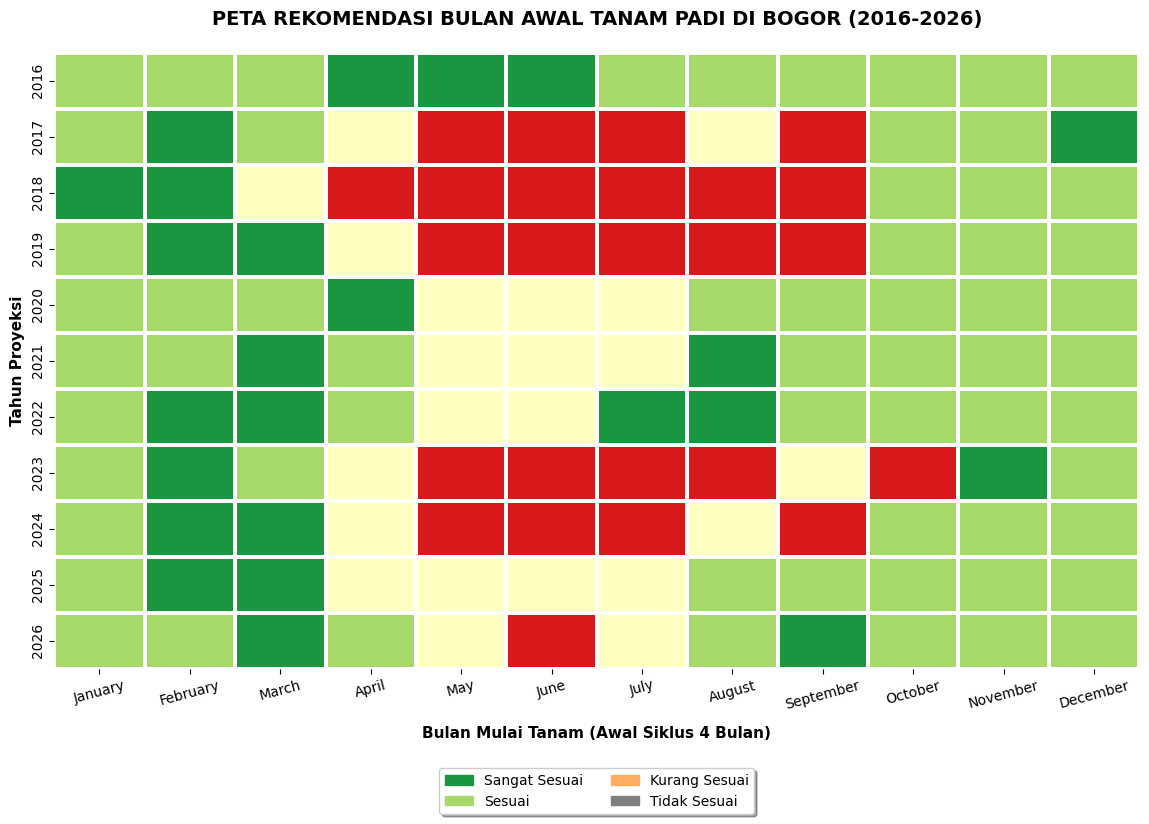

In [5]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# 1. Definisikan Warna Spesifik untuk Tiap Kategori (Urutan dari -2 s.d 3)
# -2: Abu-abu, -1: Merah, 0: Oranye, 1: Kuning, 2: Hijau Muda, 3: Hijau Tua
colors = ['#7f7f7f', '#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
custom_cmap = ListedColormap(colors)

# 2. Siapkan data untuk Heatmap (Tahun vs Bulan)
df_cycle['Tahun'] = df_cycle.index.year
df_cycle['Bulan'] = df_cycle.index.strftime('%B')

# Mapping kategori ke nilai angka
kategori_map = {
    "Tidak Sesuai (Suhu Tidak Mendukung)": -2,
    "Tidak Sesuai (Kekeringan / Air Kurang)": -1,
    "Kurang Sesuai (Rawan Banjir)": 0,
    "Kurang Sesuai (Butuh Irigasi Tambahan)": 1,
    "Sesuai (Cukup Air)": 2,
    "Sangat Sesuai (Optimal)": 3
}
df_cycle['Skor_Kesesuaian'] = df_cycle['Kesesuaian_Tanam'].map(kategori_map)

# Pivot data untuk membuat tabel Tahun vs Bulan
heatmap_data = df_cycle.pivot(index='Tahun', columns='Bulan', values='Skor_Kesesuaian')
nama_bulan = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
heatmap_data = heatmap_data.reindex(columns=nama_bulan)

# 3. Plot Heatmap (Tanpa angka di dalam kotak untuk estetika yang bersih)
plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    heatmap_data, 
    cmap=custom_cmap, 
    vmin=-2, vmax=3, # Mengunci rentang nilai agar warna tidak bergeser
    annot=False,     # Mematikan angka di dalam kotak agar rapi
    cbar=False,      # Mematikan colorbar bawaan karena kita akan buat legend custom
    linewidths=1.5, 
    linecolor='white'
)

# 4. MEMBUAT CUSTOM LEGEND (Keterangan Warna)
legend_labels = {
    'Sangat Sesuai': '#1a9641',
    'Sesuai': '#a6d96a',
    'Kurang Sesuai': '#ffffbf',
    'Kurang Sesuai': '#fdae61',
    'Tidak Sesuai': '#d7191c',
    'Tidak Sesuai': '#7f7f7f'
}

# Membuat kotak warna untuk legenda
patches = [mpatches.Patch(color=color, label=label) for label, color in legend_labels.items()]

# Meletakkan legenda di bawah heatmap agar tidak menghalangi grafik
plt.legend(
    handles=patches, 
    bbox_to_anchor=(0.5, -0.15), 
    loc='upper center', 
    ncol=2, 
    fontsize=10, 
    frameon=True,
    shadow=True
)

# Konfigurasi Teks
plt.title('PETA REKOMENDASI BULAN AWAL TANAM PADI DI BOGOR (2016-2026)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Bulan Mulai Tanam (Awal Siklus 4 Bulan)', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Tahun Proyeksi', fontsize=11, fontweight='bold')
plt.xticks(rotation=15) # Memiringkan nama bulan agar mudah dibaca

# Simpan Grafik ke Folder Gambar
plt.savefig('images/report/planting_suitability_map.png', dpi=300, bbox_inches='tight')
plt.show()